# Figure 2 - Grid search using SPARZ parameters

## Preparing the data for Figure 2
#### Doing a grid search with different kervel sizes, thresholds and compression levels

In [ ]:
## Script to perform grid search for optimal SPARZ compression parameters on microtubule data

# Setting up environment and imports
from SPARZ import SPARZIP, SPARUNZIP
import os
from tqdm import tqdm 

# Paths for input files
path1 = '/Volumes/T9/compression/microtubule_data/sequence-as-stack-MT0.N1.HD-BP+250.tif'
path2 = '/Volumes/T9/compression/microtubule_data/sequence-as-stack-MT0.N1.HD-BP-250.tif'

stem= 'MT0'

# Define ranges for grid search
kernel_sizes = list(range(5, 12, 2))  # 5, 7, 9, 11
rel_thresholds = [0.35, 0.45, 0.55, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


# Extract base filenames without extension
base_filename1 = os.path.splitext(os.path.basename(path1))[0]
base_filename2 = os.path.splitext(os.path.basename(path2))[0]


# Total number of iterations for progress bar
total_iterations = len(kernel_sizes) * len(rel_thresholds) * len(compression_levels)

In [ ]:
# Iterate over all combinations of parameters
with tqdm(total=total_iterations, desc="Grid Search Progress", unit="iteration") as pbar: # Initialize tqdm progress bar
    for kernel_size in kernel_sizes:
        for rel_thresh in rel_thresholds:
            for compression_level in compression_levels:
                # Create output paths based on parameters
                output_path = f'/Users/laurabreimann/Desktop/DNA-PAINT_2/sparz_k{kernel_size}_rt{int(rel_thresh*100)}_lev{compression_level}'
                uncompressed_path = os.path.join(output_path, 'uncompressed')
                os.makedirs(uncompressed_path, exist_ok=True)

                # SPARZIP
                z = SPARZIP(path1, stem, output_path, relative_threshold = rel_thresh, kernel_size =kernel_size)
                z.run(codec='x265', compression_level=compression_level)

                # Output files for SPARUNZIP
                path_sparse_bp1 = os.path.join(output_path, f'{base_filename1}.npz')
                path_sparse_bp2 = os.path.join(output_path, f'{base_filename2}.npz')
                mp4_1 = os.path.join(output_path, f'{base_filename1}_compression_level_{compression_level}.mp4')
                mp4_2 = os.path.join(output_path, f'{base_filename2}_compression_level_{compression_level}.mp4')

                # SPARUNZIP
                u= SPARUNZIP(path_sparse_bp1= path_sparse_bp1,
                            path_encoded_bp1= mp4_1,
                            stem= stem,
                            output_path= uncompressed_path,
                            path_sparse_bp2= path_sparse_bp2,
                            path_encoded_bp2= mp4_2,
                            use_roi = True,
                            chunk_size = 10) 
                u.run()

                # Update progress bar
                pbar.update(1)


## Images of video compression levels and decompressed images

Min value: 431, Max value: 2434


/var/folders/n4/82zt36bj3190s97jwk9jxc580000gn/T/ipykernel_12623/4240795674.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


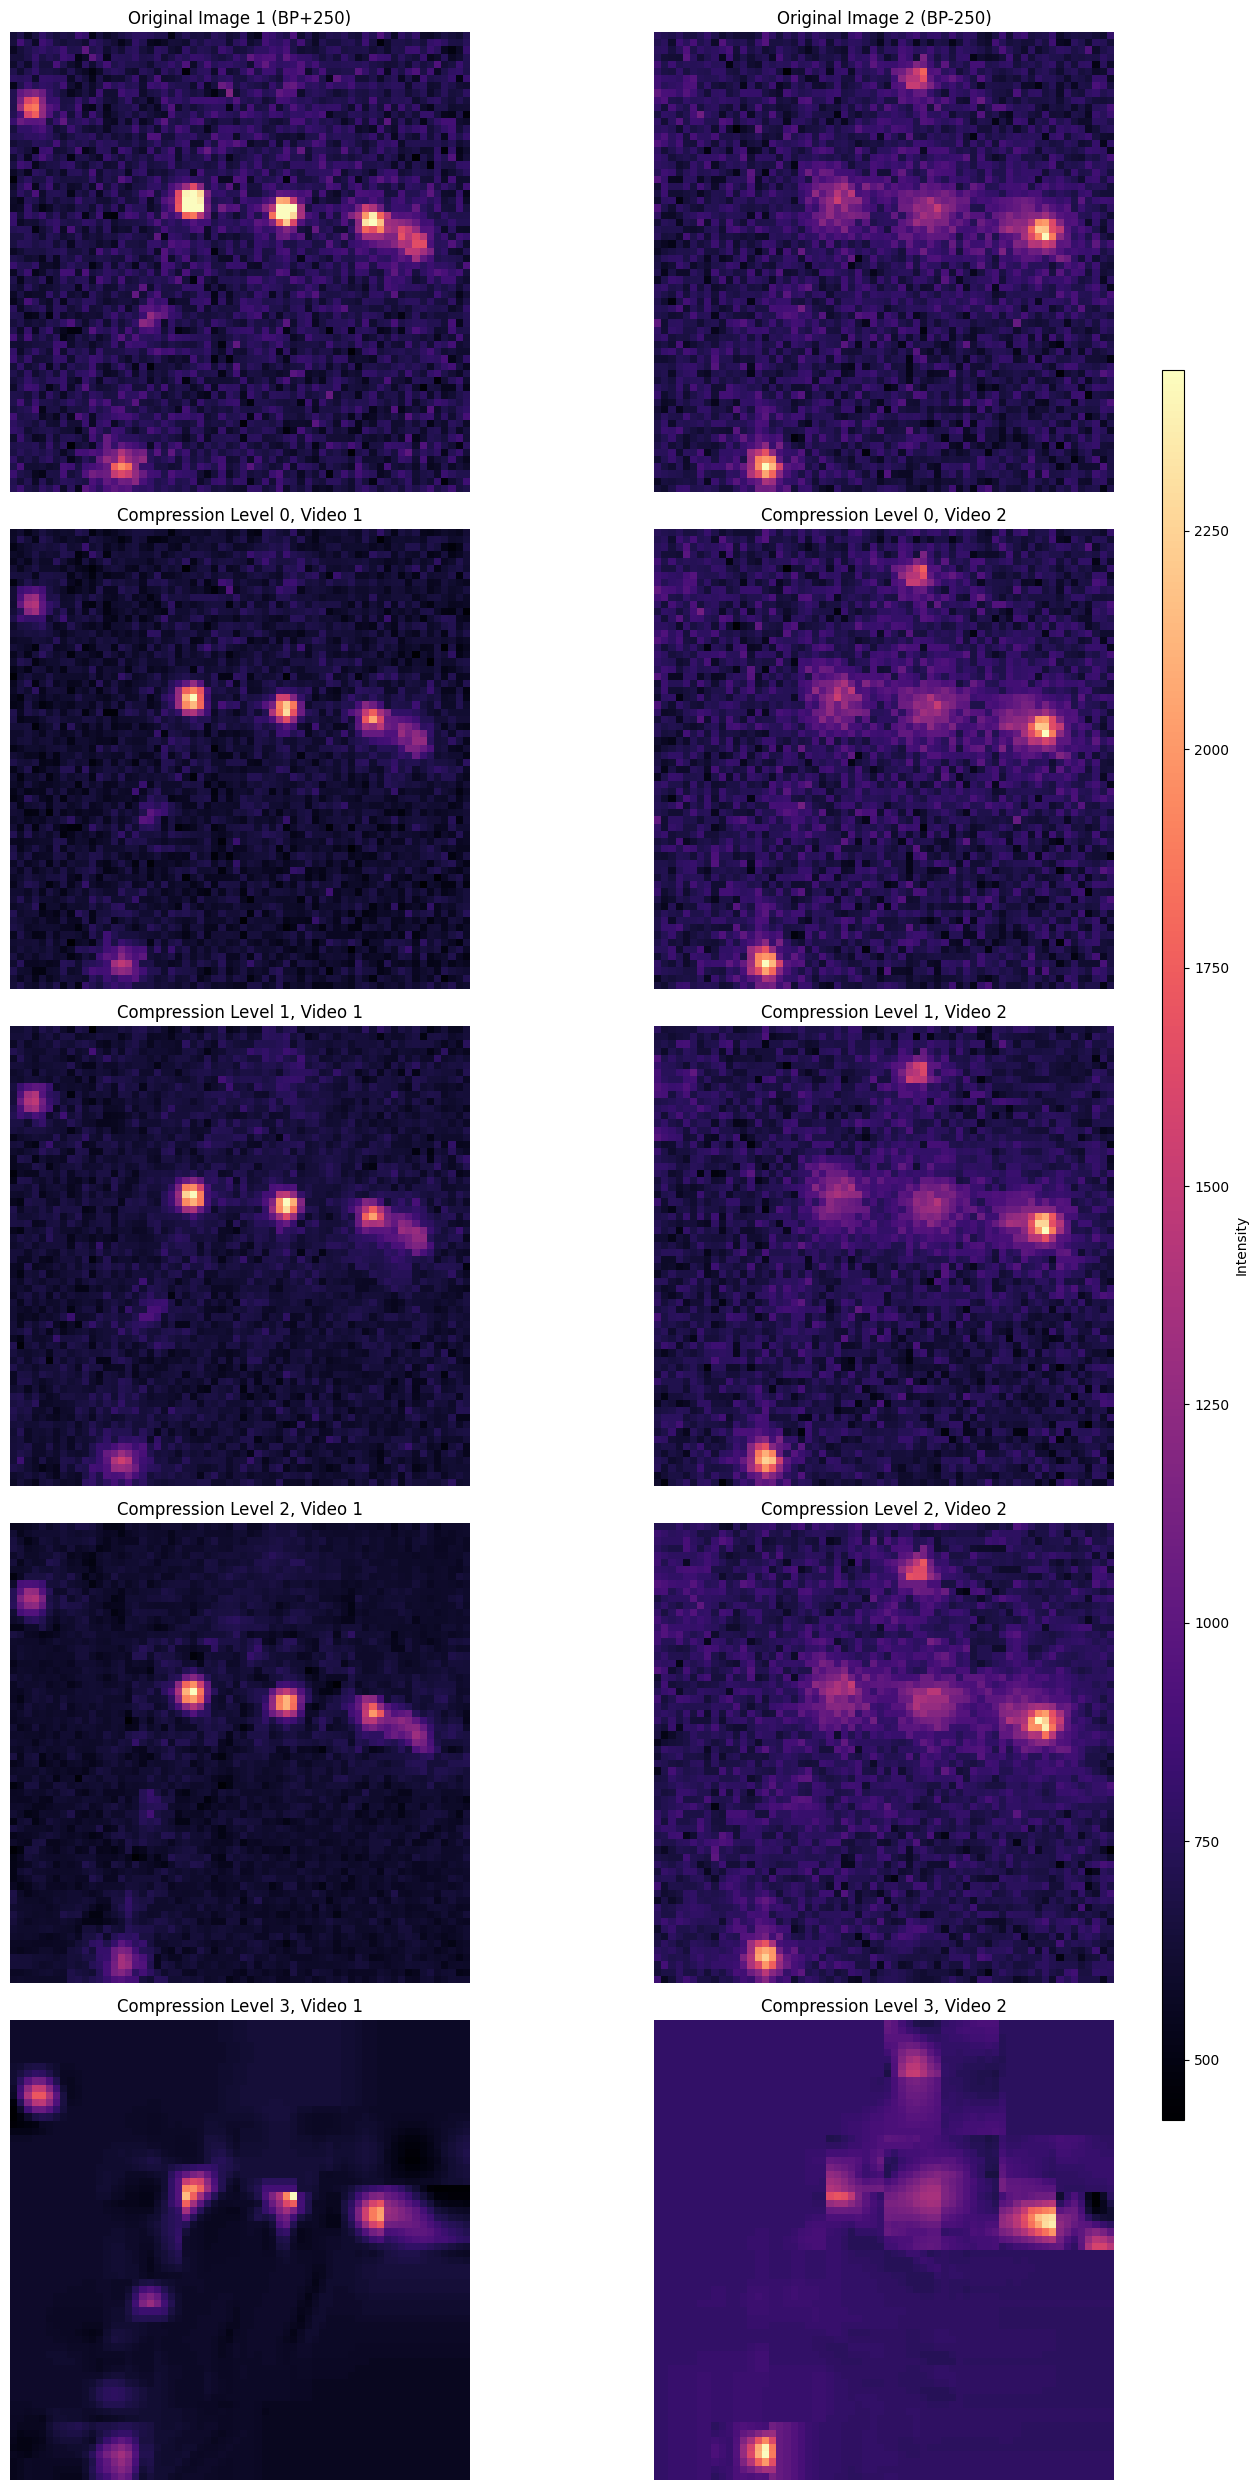

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
from reader import imread as vimread
from pathlib import Path

# Import utility functions
from analysis_utils import (
    normalize_image_16bit_to_8bit,
    read_tiff_frame,
)

# ============================================================================
# Configuration
# ============================================================================

# Base paths
DROPBOX_BASE = Path("/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_2_data")
MICROTUBULE_DATA = DROPBOX_BASE / "microtubule_data"
RAW_DATA = DROPBOX_BASE / "raw"

# Frame numbers
frame_number = 25
tiff_frame_number = 25

# Compression levels to visualize
compression_levels = [0, 1, 2, 3]

# Build video paths programmatically
video_paths = []
for level in compression_levels:
    level_dir = MICROTUBULE_DATA / f"sparz_k5_rt35_lev{level}"
    video_paths.append([
        str(level_dir / f"sequence-as-stack-MT0.N1.HD-BP+250_compression_level_{level}.mp4"),
        str(level_dir / f"sequence-as-stack-MT0.N1.HD-BP-250_compression_level_{level}.mp4")
    ])

# Original images
original_image_path1 = RAW_DATA / "sequence-as-stack-MT0.N1.HD-BP+250.tif"
original_image_path2 = RAW_DATA / "sequence-as-stack-MT0.N1.HD-BP-250.tif"

# Verify paths exist
if not original_image_path1.exists():
    raise FileNotFoundError(f"File not found: {original_image_path1}")
if not original_image_path2.exists():
    raise FileNotFoundError(f"File not found: {original_image_path2}")

# Read the original TIFF images
original_image1 = read_tiff_frame(str(original_image_path1), tiff_frame_number)
original_image2 = read_tiff_frame(str(original_image_path2), tiff_frame_number)

# Find min and max pixel values
min_val = original_image2.min()
max_val = original_image2.max()
print(f"Min value: {min_val}, Max value: {max_val}")

# Normalize images
original_image1_normalized = normalize_image_16bit_to_8bit(original_image1, min_val, max_val)

# ============================================================================
# Create Visualization
# ============================================================================

num_rows = len(video_paths) + 1
num_cols = 2

fig = plt.figure(figsize=(15, num_rows * 5))
gs = gridspec.GridSpec(num_rows, num_cols + 1, width_ratios=[1, 1, 0.05], 
                       wspace=0.3, hspace=0.3)

# Plot original images
plt.subplot(num_rows, num_cols, 1)
plt.imshow(original_image1_normalized, cmap='magma', interpolation='none')
plt.title("Original Image 1 (BP+250)")
plt.axis('off')

plt.subplot(num_rows, num_cols, 2)
plt.imshow(original_image2, cmap='magma', interpolation='none')
plt.title("Original Image 2 (BP-250)")
plt.axis('off')

# Plot compressed frames
for i, level_paths in enumerate(video_paths):
    for j, path in enumerate(level_paths):
        # Check if file exists
        if not Path(path).exists():
            print(f"Warning: Video file not found: {path}")
            continue
            
        video_dask_array = vimread(path, dtypes='uint16')
        frame_dask = video_dask_array[frame_number]
        frame_data = frame_dask.compute()
        frame_normalized = normalize_image_16bit_to_8bit(
            frame_data, 
            np.min(frame_data), 
            np.max(frame_data)
        )
        
        plt.subplot(num_rows, num_cols, (i + 1) * num_cols + j + 1)
        plt.imshow(frame_normalized, cmap='magma', interpolation='none')
        plt.title(f"Compression Level {i}, Video {j + 1}")
        plt.axis('off')

# Add colorbar
cbar_ax = fig.add_axes([0.9, 0.15, 0.015, 0.7])
norm = Normalize(vmin=min_val, vmax=max_val)
sm = ScalarMappable(cmap='magma', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Intensity')

plt.tight_layout()

# Save figure
output_path = Path("/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures")
output_path.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path / 'mp4_profiles.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Plot Jaccard similartiy for different parameter combinations

Raw localization file statistics:

Localization Statistics for: /Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_2_data/localizations/sparz_grid_search/raw/analysis/sequence-MT0.N1.HD-BP.h5r
Total localizations: 10,576
Unique frames: 1,921
Mean localizations per frame: 5.5

Spatial range (nm):
  X: -9443.0 to 6290.4
  Y: -1884.0 to 7924.2
  Z: -1379.1 to 1187.3

Localization precision:
  Mean XY error: -751.68 nm
  Mean Z error: -722.66 nm

Result codes:
  Code 2: 5,324 (50.3%)
  Code 1: 3,509 (33.2%)
  Code 3: 1,743 (16.5%)

CALCULATING JACCARD SIMILARITY

Reading raw localizations...
Raw localizations loaded: 10,576 points

Processing: sparz_k5_rt35_lev0
  Raw localizations: 10576
  Compressed localizations: 10594
  Jaccard similarity: 0.8013

Processing: sparz_k5_rt35_lev1
  Raw localizations: 10576
  Compressed localizations: 10496
  Jaccard similarity: 0.4457

Processing: sparz_k5_rt35_lev2
  Raw localizations: 10576
  Comp

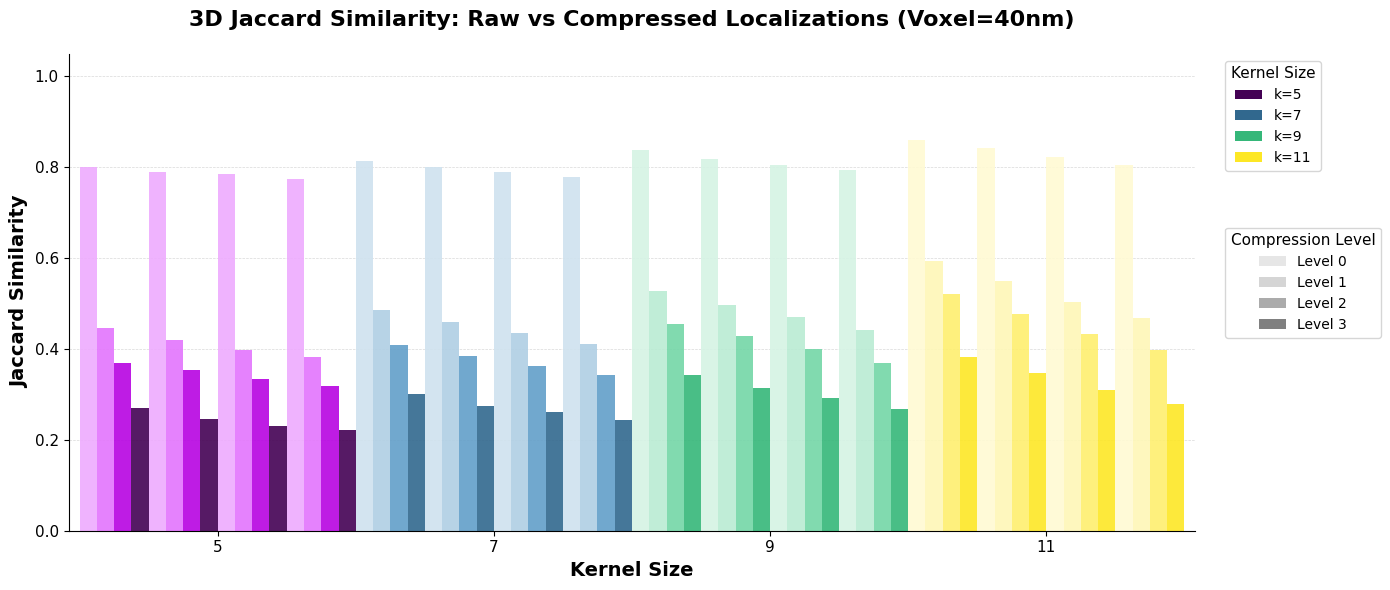

In [6]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
from pathlib import Path
import matplotlib.colors as mcolors

# Import from h5r_functions directly
from h5r_functions import get_xyz_coordinates, print_localization_stats

# Import utility functions
from analysis_utils import (
    calculate_jaccard_for_condition,
    extract_k_lev,
    lighten_color,
)

# ============================================================================
# Configuration
# ============================================================================

# Data paths
DROPBOX_BASE = Path("/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_2_data")
localizations_folder = DROPBOX_BASE / "localizations" / "sparz_grid_search"
raw_localizations_file = localizations_folder / "raw" / "analysis" / "sequence-MT0.N1.HD-BP.h5r"

# Output paths
output_csv = Path("/Users/laurabreimann/Desktop/microtubule_jaccard.csv")
output_figure = Path("/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_2_Jaccard_barplot.pdf")

# Voxel size for Jaccard calculation (in nm)
VOXEL_SIZE = 40  

# ============================================================================
# Inspect Raw Localizations (Optional)
# ============================================================================

print("Raw localization file statistics:")
print_localization_stats(str(raw_localizations_file))

# ============================================================================
# Calculate Jaccard Similarity for All Conditions
# ============================================================================

print(f"\n{'='*80}")
print("CALCULATING JACCARD SIMILARITY")
print(f"{'='*80}\n")

if not raw_localizations_file.exists():
    raise FileNotFoundError(f"Raw localization file not found: {raw_localizations_file}")

# Read raw localizations once
print("Reading raw localizations...")
raw_locs = get_xyz_coordinates(str(raw_localizations_file))
print(f"Raw localizations loaded: {len(raw_locs):,} points\n")

jaccard_results = []

for folder in natsorted(os.listdir(localizations_folder)):
    if folder.startswith('.') or folder == 'raw' or not folder.startswith('sparz_'):
        continue
    
    print(f"Processing: {folder}")
    
    compressed_file = localizations_folder / folder / "analysis" / "sequence-MT0.N1.HD-BP.h5r"
    
    if not compressed_file.exists():
        print(f"  Warning: Localization file not found")
        continue
    
    try:
        # Read compressed localizations
        compressed_locs = get_xyz_coordinates(str(compressed_file))
        
        # Calculate Jaccard similarity
        jaccard_score = calculate_jaccard_for_condition(
            raw_locs,
            compressed_locs,
            voxel_size=VOXEL_SIZE
        )
        
        print(f"  Jaccard similarity: {jaccard_score:.4f}\n")
        
        # Extract parameters from folder name
        k, lev = extract_k_lev(folder)
        threshold_match = re.search(r'rt(\d+)', folder)
        threshold = int(threshold_match.group(1)) if threshold_match else None
        
        jaccard_results.append({
            'Folder': folder,
            'Jaccard': jaccard_score,
            'k': k,
            'lev': lev,
            'threshold': threshold
        })
        
    except Exception as e:
        print(f"  Error: {e}\n")
        import traceback
        traceback.print_exc()
        continue

# Create DataFrame and save
jaccard_df = pd.DataFrame(jaccard_results)
jaccard_df.to_csv(output_csv, index=False)
print(f"\n{'='*80}")
print(f"Results saved to: {output_csv}")
print(f"Total conditions processed: {len(jaccard_df)}")
print(f"{'='*80}\n")

# ============================================================================
# Create Bar Plot with Kernel Grouping
# ============================================================================

# Read the results
jaccard_df = pd.read_csv(output_csv)

# Get unique values and sort them
k_values = sorted(jaccard_df['k'].unique())
threshold_values = sorted(jaccard_df['threshold'].unique())
compression_levels = sorted(jaccard_df['lev'].unique())

print(f"Kernel sizes: {k_values}")
print(f"Thresholds: {threshold_values}")
print(f"Compression levels: {compression_levels}\n")

# Create base colors for kernel sizes (same as SSIM plot)
k_base_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
k_color_map = {k: color for k, color in zip(k_values, k_base_colors)}

# FIXED: Direct mapping for lighten_color function
# In lighten_color: amount=0 is lightest, amount=1 is darkest (original)
saturation_levels = {
    0: 0.2,   # Lightest (maximum lightening)
    1: 0.33,  # Light-medium
    2: 0.66,  # Medium-dark  
    3: 1.0    # Darkest (original color, no lightening)
}

# Function to get color based on kernel size and compression level
def get_color(k, lev):
    """Get color based on kernel size and compression level."""
    base_color = k_color_map[k]
    amount = saturation_levels[lev]
    return lighten_color(base_color, amount)

# Prepare data for plotting
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate dimensions
n_kernels = len(k_values)
n_thresholds = len(threshold_values)
n_levels = len(compression_levels)
bar_width = 0.8  # Width of each individual bar
bar_spacing = 0  # No space between bars

x_positions = []
colors = []
jaccard_scores = []
x_current = 0

# Store positions for kernel group centers (for x-axis labels)
kernel_group_centers = []

# Iterate: Kernels -> Thresholds -> Compression Levels
for i, k in enumerate(k_values):
    kernel_start = x_current
    
    for j, threshold in enumerate(threshold_values):
        for l, lev in enumerate(compression_levels):
            # Find the data point
            data_point = jaccard_df[
                (jaccard_df['k'] == k) & 
                (jaccard_df['threshold'] == threshold) & 
                (jaccard_df['lev'] == lev)
            ]
            
            if len(data_point) > 0:
                # Add position
                x_positions.append(x_current)
                
                # Get color
                color = get_color(k, lev)
                colors.append(color)
                
                # Get Jaccard score
                jaccard_scores.append(data_point['Jaccard'].values[0])
                
                # Move to next bar position
                x_current += bar_width + bar_spacing
    
    # Calculate center of this kernel group
    kernel_end = x_current
    kernel_group_centers.append((kernel_start + kernel_end - bar_width) / 2)

# Create bar plot
bars = ax.bar(x_positions, jaccard_scores, width=bar_width, color=colors, 
              edgecolor='none', alpha=0.9)

# Customize plot
ax.set_xlabel('Kernel Size', fontsize=14, fontweight='bold')
ax.set_ylabel('Jaccard Similarity', fontsize=14, fontweight='bold')
ax.set_title(f'3D Jaccard Similarity: Raw vs Compressed Localizations (Voxel={VOXEL_SIZE}nm)', 
             fontsize=16, fontweight='bold', pad=20)

# Set x-axis labels at kernel group centers
ax.set_xticks(kernel_group_centers)
ax.set_xticklabels([f'{k}' for k in k_values], fontsize=12)

# Add grid
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=11)

# Set y-axis limits
ax.set_ylim([0, 1.05])

# Remove extra space around bars
ax.margins(x=0.01)

# Create custom legends
from matplotlib.patches import Patch

# Legend 1: Kernel sizes (colors)
legend_elements_k = [
    Patch(facecolor=k_color_map[k], label=f'k={k}')
    for k in k_values
]

# Legend 2: Compression levels (saturations) showing light to dark
legend_elements_lev = []
sample_base_color = np.array([0.5, 0.5, 0.5, 1.0])
for lev in compression_levels:
    amount = saturation_levels[lev]
    color = lighten_color(sample_base_color, amount)
    legend_elements_lev.append(Patch(facecolor=color, label=f'Level {lev}'))

# Add legends
legend1 = ax.legend(handles=legend_elements_k, loc='upper left', 
                    bbox_to_anchor=(1.02, 1), title='Kernel Size', 
                    fontsize=10, title_fontsize=11, frameon=True)
legend2 = ax.legend(handles=legend_elements_lev, loc='upper left', 
                    bbox_to_anchor=(1.02, 0.65), title='Compression Level', 
                    fontsize=10, title_fontsize=11, frameon=True)
ax.add_artist(legend1)

plt.tight_layout()

# Save figure
output_figure.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_figure, format='pdf', bbox_inches='tight', dpi=300)
print(f"Figure saved to: {output_figure}\n")

plt.show()

## Plot SSIM vs file size

Original file size: 41.65 MB
Processing: sparz_k5_rt35_lev0
  Total file size: 27.82 MB (66.79%)
  SSIM BP+250: 0.9994
  SSIM BP-250: 0.9995
  SSIM Median: 0.9994
Processing: sparz_k5_rt35_lev1
  Total file size: 16.88 MB (40.54%)
  SSIM BP+250: 0.9648
  SSIM BP-250: 0.9704
  SSIM Median: 0.9676
Processing: sparz_k5_rt35_lev2
  Total file size: 15.24 MB (36.59%)
  SSIM BP+250: 0.9440
  SSIM BP-250: 0.9585
  SSIM Median: 0.9512
Processing: sparz_k5_rt35_lev3
  Total file size: 14.50 MB (34.82%)
  SSIM BP+250: 0.8626
  SSIM BP-250: 0.8667
  SSIM Median: 0.8647
Processing: sparz_k5_rt45_lev0
  Total file size: 19.97 MB (47.96%)
  SSIM BP+250: 0.9984
  SSIM BP-250: 0.9988
  SSIM Median: 0.9986
Processing: sparz_k5_rt45_lev1
  Total file size: 9.04 MB (21.71%)
  SSIM BP+250: 0.9035
  SSIM BP-250: 0.9236
  SSIM Median: 0.9136
Processing: sparz_k5_rt45_lev2
  Total file size: 7.40 MB (17.76%)
  SSIM BP+250: 0.8565
  SSIM BP-250: 0.8987
  SSIM Median: 0.8776
Processing: sparz_k5_rt45_lev3
  To

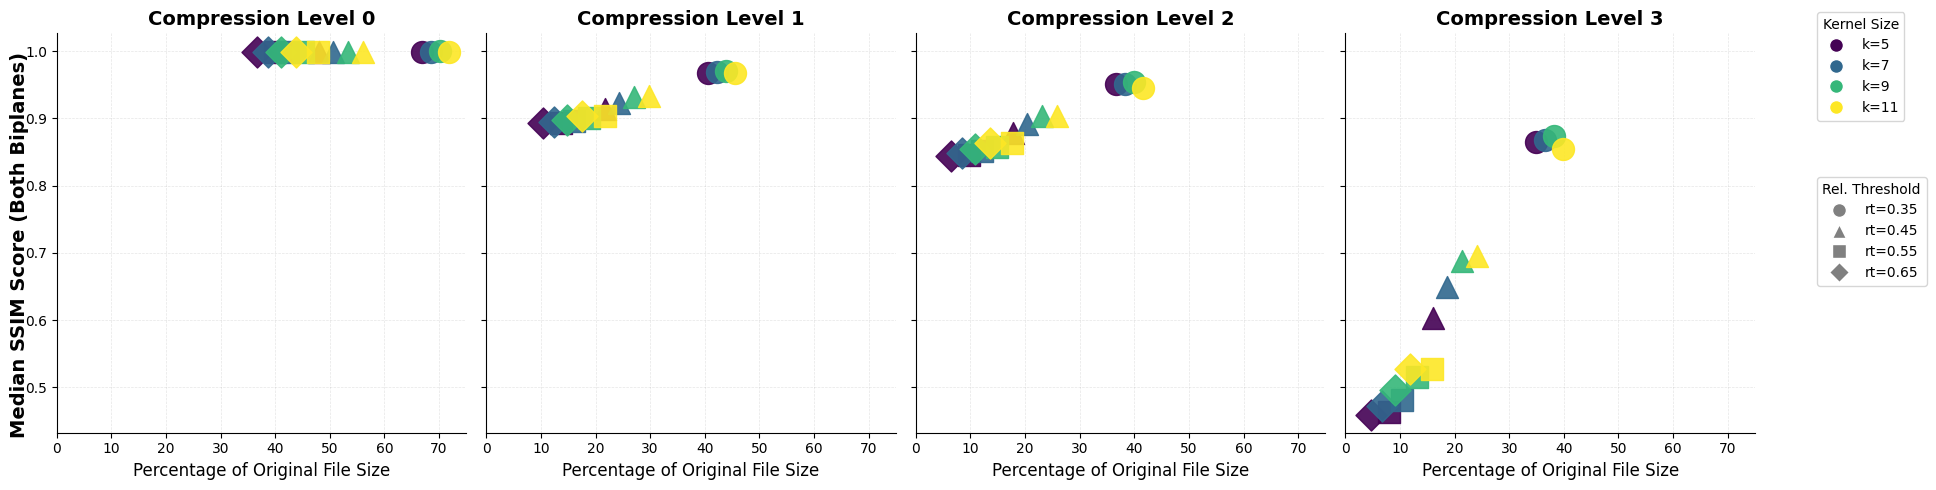


SUMMARY STATISTICS

Total conditions tested: 64

SSIM Range: 0.4594 - 0.9995
File Size Range: 4.61% - 71.84%

Best compression (smallest file size with SSIM > 0.95):
                Folder  SSIM_median  percentage_size  k  lev  threshold
12  sparz_k5_rt65_lev0     0.998274        36.583271  5    0         65
2   sparz_k5_rt35_lev2     0.951244        36.592624  5    2         35
18  sparz_k7_rt35_lev2     0.951305        38.242466  7    2         35

Best quality (highest SSIM):
                 Folder  SSIM_median  percentage_size   k  lev  threshold
32   sparz_k9_rt35_lev0     0.999502        70.212983   9    0         35
48  sparz_k11_rt35_lev0     0.999460        71.840755  11    0         35
16   sparz_k7_rt35_lev0     0.999456        68.444610   7    0         35


In [3]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
from pathlib import Path

# Import utility functions
from analysis_utils import (
    calculate_ssim_biplane,
    get_total_size_of_files,
    extract_k_lev,
)

# ============================================================================
# Configuration
# ============================================================================

# Data paths
DROPBOX_BASE = Path("/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_2_data")
main_folder = DROPBOX_BASE / "microtubule_data"
original_folder = DROPBOX_BASE / "raw"

# Output path
output_csv = Path("/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/microtubule_ssim.csv")
output_figure = Path("/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_2_SSIM_filesize.pdf")

# Biplane file patterns
BP_POSITIVE_PATTERN = "BP+250"
BP_NEGATIVE_PATTERN = "BP-250"

# ============================================================================
# Calculate Original File Size
# ============================================================================

original_file_size = get_total_size_of_files(str(original_folder), ['.tif', '.tiff'])
print(f'Original file size: {original_file_size / 1e6:.2f} MB')

# ============================================================================
# Process Grid Search Results
# ============================================================================

ssim_df_list = []

for folder in natsorted(os.listdir(main_folder)):
    if folder.startswith('.') or not folder.startswith('sparz_'):
        continue
    
    print(f"Processing: {folder}")
    
    uncompressed_folder = main_folder / folder / 'uncompressed'
    
    if not uncompressed_folder.exists():
        print(f"  Warning: uncompressed folder not found for {folder}")
        continue
    
    try:
        ssim_results = calculate_ssim_biplane(
            str(original_folder),
            str(uncompressed_folder),
            BP_POSITIVE_PATTERN,
            BP_NEGATIVE_PATTERN
        )
        
        total_file_size = get_total_size_of_files(str(main_folder / folder), ['.mp4', '.npz'])
        file_size_percentage = (total_file_size / original_file_size) * 100
        
        print(f"  Total file size: {total_file_size / 1e6:.2f} MB ({file_size_percentage:.2f}%)")
        print(f"  SSIM BP+250: {ssim_results['ssim_bp_positive']:.4f}")
        print(f"  SSIM BP-250: {ssim_results['ssim_bp_negative']:.4f}")
        print(f"  SSIM Median: {ssim_results['ssim_median']:.4f}")
        
        k, lev = extract_k_lev(folder)
        threshold_match = re.search(r'rt(\d+)', folder)
        threshold = int(threshold_match.group(1)) if threshold_match else None
        
        ssim_df_list.append({
            'Folder': folder,
            'bp_positive_file': ssim_results['bp_positive_file'],
            'bp_negative_file': ssim_results['bp_negative_file'],
            'SSIM_BP_positive': ssim_results['ssim_bp_positive'],
            'SSIM_BP_negative': ssim_results['ssim_bp_negative'],
            'SSIM_median': ssim_results['ssim_median'],  
            'Size': total_file_size,
            'percentage_size': file_size_percentage,
            'k': k,
            'lev': lev,
            'threshold': threshold
        })
        
    except Exception as e:
        print(f"  Error processing {folder}: {e}")
        continue

ssim_df = pd.DataFrame(ssim_df_list)
ssim_df.to_csv(output_csv, index=False)
print(f"\nResults saved to: {output_csv}")

# ============================================================================
# Visualize Results
# ============================================================================

ssim_df = pd.read_csv(output_csv)

# Define visualization parameters
k_values = sorted(ssim_df['k'].unique())
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

# Marker mapping for thresholds
threshold_markers = {
    65: 'D',  # 0.65: diamond
    55: 's',  # 0.55: square
    45: '^',  # 0.45: triangle
    35: 'o'   # 0.35: circle
}

# Create a color map for 'k' values
color_map = {k: color for k, color in zip(k_values, k_colors)}

# Use the dataframe as-is (one row per folder)
folder_stats = ssim_df.copy()

# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, (level, group) in enumerate(folder_stats.groupby('lev')):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size', fontsize=12)
    ax.set_title(f'Compression Level {level}', fontsize=14, fontweight='bold')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    ax.set_xlim(0, 75)
    
    for k, data in group.groupby('k'):
        for rt, rt_data in data.groupby('threshold'):
            if rt in threshold_markers:
                ax.scatter(
                    rt_data['percentage_size'], 
                    rt_data['SSIM_median'],  
                    color=color_map[k], 
                    s=250, 
                    marker=threshold_markers[rt], 
                    alpha=0.9,
                    label=f'k={k}, rt={rt}',
                    zorder=3
                )

# Style adjustments
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10)


fig.text(0.02, 0.5, 'Median SSIM Score (Both Biplanes)', 
         va='center', rotation='vertical', fontsize=14, fontweight='bold')

# Create custom legend
from matplotlib.lines import Line2D

# Legend for kernel sizes
legend_elements_k = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=color_map[k], markersize=10, 
           label=f'k={k}') 
    for k in k_values
]

# Legend for thresholds
threshold_values = sorted([t for t in ssim_df['threshold'].unique() if t in threshold_markers])
legend_elements_rt = [
    Line2D([0], [0], marker=threshold_markers[rt], color='w', 
           markerfacecolor='gray', markersize=10, 
           label=f'rt={rt/100:.2f}')  # Display as 0.35, 0.45, etc.
    for rt in threshold_values
]

# Add legends
fig.legend(handles=legend_elements_k, loc='upper left', bbox_to_anchor=(0.92, 0.98), 
          title='Kernel Size', fontsize=10)
fig.legend(handles=legend_elements_rt, loc='upper left', bbox_to_anchor=(0.92, 0.65), 
          title='Rel. Threshold', fontsize=10)

plt.tight_layout(rect=[0.02, 0, 0.90, 1])

# Save the plot
output_figure.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_figure, format='pdf', bbox_inches='tight', dpi=300)
print(f"\nFigure saved to: {output_figure}")

plt.show()

# ============================================================================
# Print Summary Statistics
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTotal conditions tested: {len(ssim_df)}")
print(f"\nSSIM Range: {ssim_df['SSIM_median'].min():.4f} - {ssim_df['SSIM_median'].max():.4f}")
print(f"File Size Range: {ssim_df['percentage_size'].min():.2f}% - {ssim_df['percentage_size'].max():.2f}%")

print("\nBest compression (smallest file size with SSIM > 0.95):")
best_compression = ssim_df[ssim_df['SSIM_median'] > 0.95].nsmallest(3, 'percentage_size')
if len(best_compression) > 0:
    print(best_compression[['Folder', 'SSIM_median', 'percentage_size', 'k', 'lev', 'threshold']])
else:
    print("No conditions with SSIM > 0.95")

print("\nBest quality (highest SSIM):")
best_quality = ssim_df.nlargest(3, 'SSIM_median')
print(best_quality[['Folder', 'SSIM_median', 'percentage_size', 'k', 'lev', 'threshold']])

# Plot gird search overview

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib.colors as mcolors

# Import utility functions
from analysis_utils import (
    extract_parameters,
    reconstruct_array,
)

# Define the parameters used in grid search
kernel_sizes = list(range(5, 12, 2))  # 5, 7, 9, 11
rel_thresholds = [0.35, 0.45, 0.55, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


In [8]:

# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    # Double the number of columns to accommodate two images per condition
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds) * 2, figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['sequence-as-stack-MT0.N1.HD-BP-250.npz', 'sequence-as-stack-MT0.N1.HD-BP+250.npz'] # this is for the microtubule data
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) * 2 + index


                            # Set color for values to #eeeeee
                            cmap = plt.cm.gray
                            cmap.set_under('#eeeeee')


                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')



                            # Set title for the first image of the pair
                            if index == 0:
                                axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')

    plt.tight_layout()

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_260120.pdf', format='pdf')  

    plt.show()


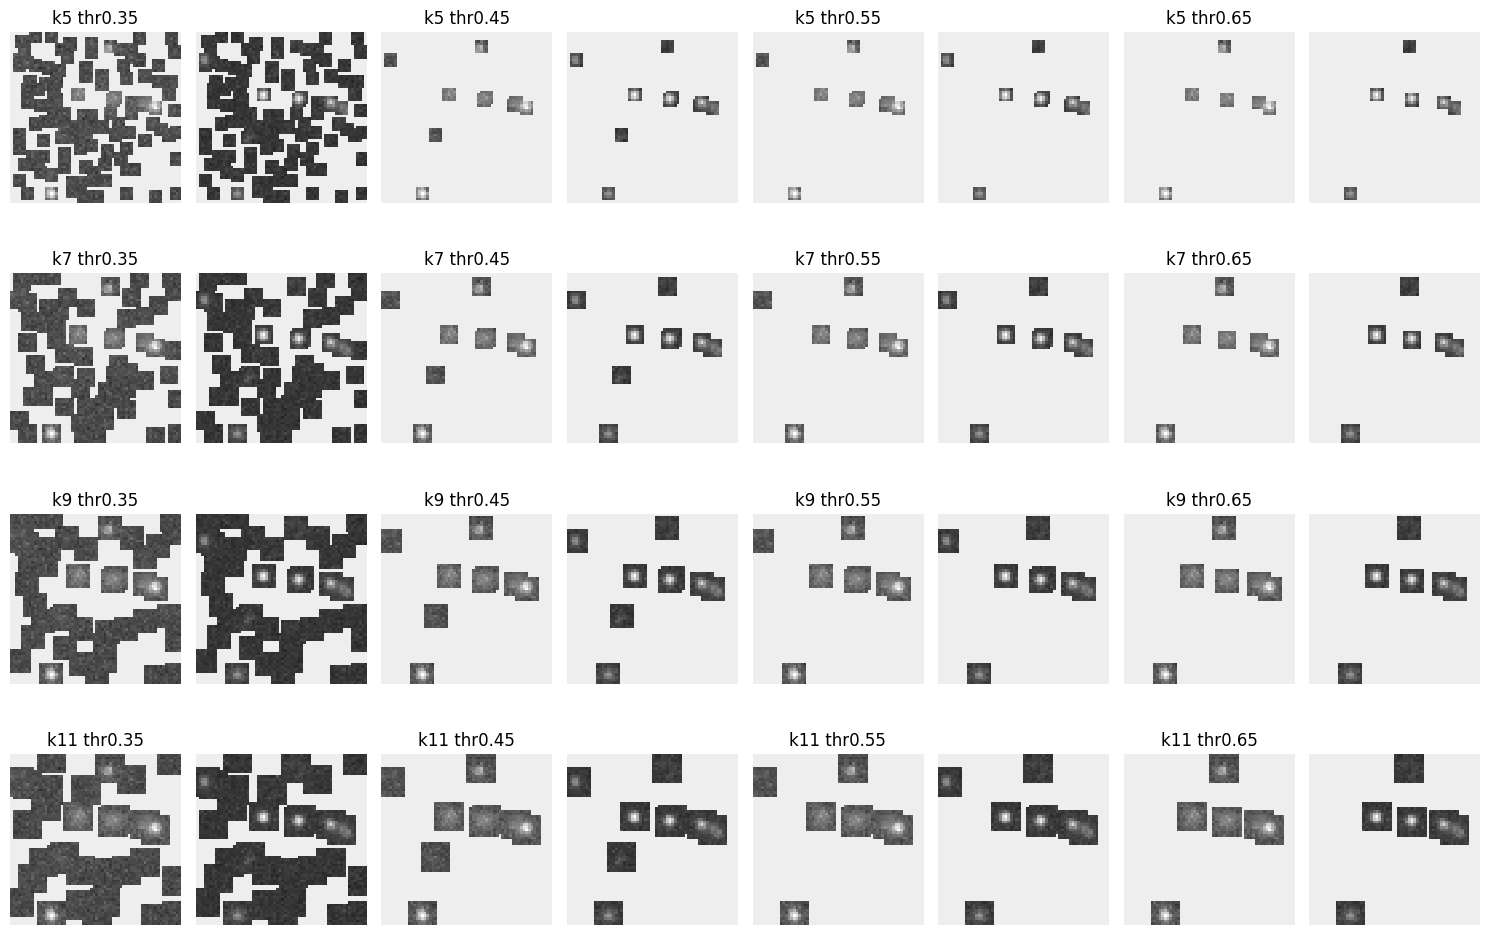

In [9]:
# Main folder path containing the npz files
main_folder_path = "/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_2_data/microtubule_data"
# Load and plot
load_and_plot_npz_files(main_folder_path)

## Number of localizations 


COUNTING LOCALIZATIONS

Reading raw localizations...
Raw localizations: 10,576 points

Processing: sparz_k5_rt35_lev0
  Compressed localizations: 10,594 (100.2% of raw)
Processing: sparz_k5_rt35_lev1
  Compressed localizations: 10,496 (99.2% of raw)
Processing: sparz_k5_rt35_lev2
  Compressed localizations: 10,492 (99.2% of raw)
Processing: sparz_k5_rt35_lev3
  Compressed localizations: 9,888 (93.5% of raw)
Processing: sparz_k5_rt45_lev0
  Compressed localizations: 10,606 (100.3% of raw)
Processing: sparz_k5_rt45_lev1
  Compressed localizations: 10,264 (97.0% of raw)
Processing: sparz_k5_rt45_lev2
  Compressed localizations: 10,287 (97.3% of raw)
Processing: sparz_k5_rt45_lev3
  Compressed localizations: 9,701 (91.7% of raw)
Processing: sparz_k5_rt55_lev0
  Compressed localizations: 10,551 (99.8% of raw)
Processing: sparz_k5_rt55_lev1
  Compressed localizations: 10,356 (97.9% of raw)
Processing: sparz_k5_rt55_lev2
  Compressed localizations: 10,173 (96.2% of raw)
Processing: sparz_k5_

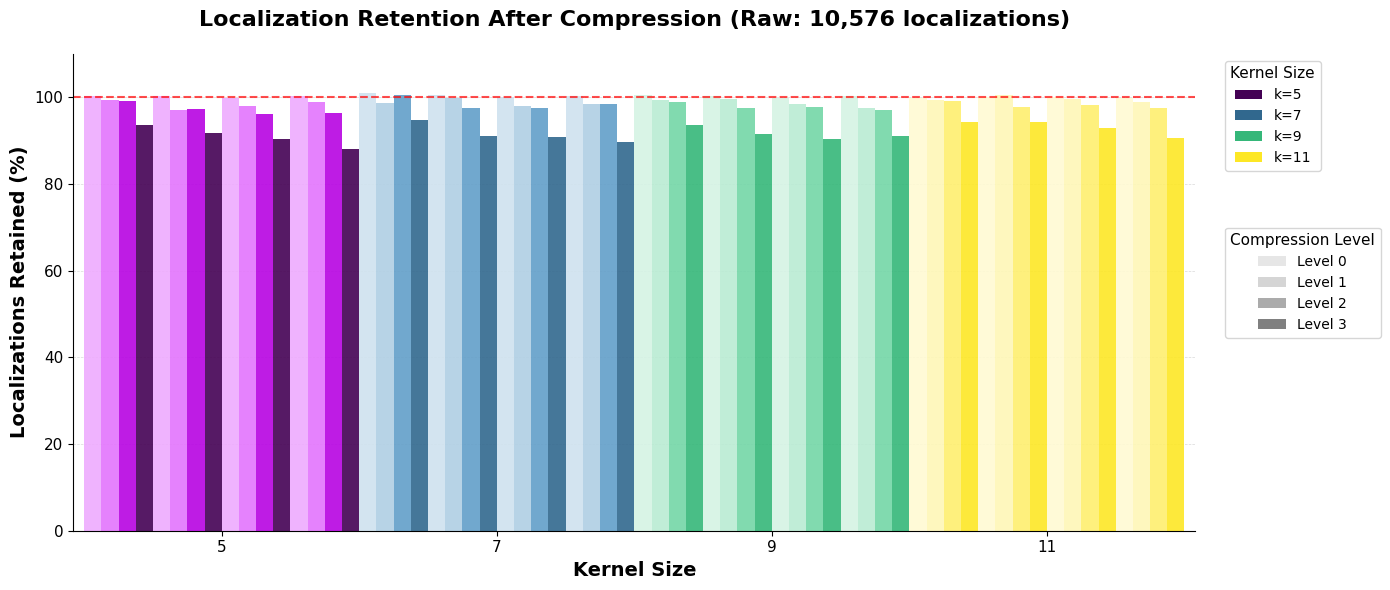

LOCALIZATION RETENTION SUMMARY

Raw localizations: 10,576
Total conditions tested: 64

Retention Range: 88.1% - 101.0%
Mean Retention: 97.2%
Median Retention: 98.4%

Highest retention (most localizations kept):
             Folder  n_compressed  percentage  k  lev  threshold
 sparz_k7_rt35_lev0         10680  100.983359  7    0         35
sparz_k11_rt45_lev1         10634  100.548411 11    1         45
 sparz_k9_rt35_lev0         10623  100.444402  9    0         35
 sparz_k7_rt35_lev2         10621  100.425492  7    2         35
 sparz_k7_rt45_lev0         10616  100.378215  7    0         45

Lowest retention (fewest localizations kept):
             Folder  n_compressed  percentage  k  lev  threshold
 sparz_k5_rt65_lev3          9313   88.057867  5    3         65
 sparz_k7_rt65_lev3          9482   89.655825  7    3         65
 sparz_k5_rt55_lev3          9547   90.270424  5    3         55
 sparz_k9_rt55_lev3          9564   90.431165  9    3         55
sparz_k11_rt65_lev3        

In [8]:
# ============================================================================
# Calculate Number of Localizations for All Conditions
# ============================================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
from pathlib import Path

# Import from h5r_functions directly
from h5r_functions import get_xyz_coordinates

# Import utility functions
from analysis_utils import extract_k_lev, lighten_color

# ============================================================================
# Configuration
# ============================================================================

# Data paths
DROPBOX_BASE = Path("/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_2_data")
localizations_folder = DROPBOX_BASE / "localizations" / "sparz_grid_search"
raw_localizations_file = localizations_folder / "raw" / "analysis" / "sequence-MT0.N1.HD-BP.h5r"

# Output paths
output_csv = Path("/Users/laurabreimann/Desktop/microtubule_localization_counts.csv")
output_figure = Path("/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_2_Localization_counts_barplot.pdf")

# ============================================================================
# Count Localizations for All Conditions
# ============================================================================

print(f"\n{'='*80}")
print("COUNTING LOCALIZATIONS")
print(f"{'='*80}\n")

if not raw_localizations_file.exists():
    raise FileNotFoundError(f"Raw localization file not found: {raw_localizations_file}")

# Read raw localizations once
print("Reading raw localizations...")
raw_locs = get_xyz_coordinates(str(raw_localizations_file))
n_raw = len(raw_locs)
print(f"Raw localizations: {n_raw:,} points\n")

localization_results = []

for folder in natsorted(os.listdir(localizations_folder)):
    if folder.startswith('.') or folder == 'raw' or not folder.startswith('sparz_'):
        continue
    
    print(f"Processing: {folder}")
    
    compressed_file = localizations_folder / folder / "analysis" / "sequence-MT0.N1.HD-BP.h5r"
    
    if not compressed_file.exists():
        print(f"  Warning: Localization file not found")
        continue
    
    try:
        # Read compressed localizations
        compressed_locs = get_xyz_coordinates(str(compressed_file))
        n_compressed = len(compressed_locs)
        percentage = (n_compressed / n_raw) * 100
        
        print(f"  Compressed localizations: {n_compressed:,} ({percentage:.1f}% of raw)")
        
        # Extract parameters from folder name
        k, lev = extract_k_lev(folder)
        threshold_match = re.search(r'rt(\d+)', folder)
        threshold = int(threshold_match.group(1)) if threshold_match else None
        
        localization_results.append({
            'Folder': folder,
            'n_raw': n_raw,
            'n_compressed': n_compressed,
            'percentage': percentage,
            'k': k,
            'lev': lev,
            'threshold': threshold
        })
        
    except Exception as e:
        print(f"  Error: {e}\n")
        import traceback
        traceback.print_exc()
        continue

# Create DataFrame and save
loc_df = pd.DataFrame(localization_results)
loc_df.to_csv(output_csv, index=False)
print(f"\n{'='*80}")
print(f"Results saved to: {output_csv}")
print(f"Total conditions processed: {len(loc_df)}")
print(f"{'='*80}\n")

# ============================================================================
# Create Bar Plot with Kernel Grouping
# ============================================================================

# Read the results
loc_df = pd.read_csv(output_csv)

# Get unique values and sort them
k_values = sorted(loc_df['k'].unique())
threshold_values = sorted(loc_df['threshold'].unique())
compression_levels = sorted(loc_df['lev'].unique())

print(f"Kernel sizes: {k_values}")
print(f"Thresholds: {threshold_values}")
print(f"Compression levels: {compression_levels}\n")

# Create base colors for kernel sizes (same as other plots)
k_base_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
k_color_map = {k: color for k, color in zip(k_values, k_base_colors)}

# Saturation levels for compression levels
saturation_levels = {
    0: 0.2,   # Lightest
    1: 0.33,  # Light-medium
    2: 0.66,  # Medium-dark  
    3: 1.0    # Darkest
}

# Function to get color based on kernel size and compression level
def get_color(k, lev):
    """Get color based on kernel size and compression level."""
    base_color = k_color_map[k]
    amount = saturation_levels[lev]
    return lighten_color(base_color, amount)

# Prepare data for plotting
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate dimensions
n_kernels = len(k_values)
n_thresholds = len(threshold_values)
n_levels = len(compression_levels)
bar_width = 0.8
bar_spacing = 0

x_positions = []
colors = []
loc_counts = []
x_current = 0

# Store positions for kernel group centers
kernel_group_centers = []

# Iterate: Kernels -> Thresholds -> Compression Levels
for i, k in enumerate(k_values):
    kernel_start = x_current
    
    for j, threshold in enumerate(threshold_values):
        for l, lev in enumerate(compression_levels):
            # Find the data point
            data_point = loc_df[
                (loc_df['k'] == k) & 
                (loc_df['threshold'] == threshold) & 
                (loc_df['lev'] == lev)
            ]
            
            if len(data_point) > 0:
                # Add position
                x_positions.append(x_current)
                
                # Get color
                color = get_color(k, lev)
                colors.append(color)
                
                # Get localization count (as percentage of raw)
                loc_counts.append(data_point['percentage'].values[0])
                
                # Move to next bar position
                x_current += bar_width + bar_spacing
    
    # Calculate center of this kernel group
    kernel_end = x_current
    kernel_group_centers.append((kernel_start + kernel_end - bar_width) / 2)

# Create bar plot
bars = ax.bar(x_positions, loc_counts, width=bar_width, color=colors, 
              edgecolor='none', alpha=0.9)

# Customize plot
ax.set_xlabel('Kernel Size', fontsize=14, fontweight='bold')
ax.set_ylabel('Localizations Retained (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Localization Retention After Compression (Raw: {n_raw:,} localizations)', 
             fontsize=16, fontweight='bold', pad=20)

# Set x-axis labels at kernel group centers
ax.set_xticks(kernel_group_centers)
ax.set_xticklabels([f'{k}' for k in k_values], fontsize=12)

# Add grid
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Add 100% reference line
ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='100% (Raw)')

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=11)

# Set y-axis limits (adjust based on your data)
ax.set_ylim([0, 110])

# Remove extra space around bars
ax.margins(x=0.01)

# Create custom legends
from matplotlib.patches import Patch

# Legend 1: Kernel sizes (colors)
legend_elements_k = [
    Patch(facecolor=k_color_map[k], label=f'k={k}')
    for k in k_values
]

# Legend 2: Compression levels (saturations)
legend_elements_lev = []
sample_base_color = np.array([0.5, 0.5, 0.5, 1.0])
for lev in compression_levels:
    amount = saturation_levels[lev]
    color = lighten_color(sample_base_color, amount)
    legend_elements_lev.append(Patch(facecolor=color, label=f'Level {lev}'))

# Add legends
legend1 = ax.legend(handles=legend_elements_k, loc='upper left', 
                    bbox_to_anchor=(1.02, 1), title='Kernel Size', 
                    fontsize=10, title_fontsize=11, frameon=True)
legend2 = ax.legend(handles=legend_elements_lev, loc='upper left', 
                    bbox_to_anchor=(1.02, 0.65), title='Compression Level', 
                    fontsize=10, title_fontsize=11, frameon=True)
ax.add_artist(legend1)

plt.tight_layout()

# Save figure
output_figure.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_figure, format='pdf', bbox_inches='tight', dpi=300)
print(f"Figure saved to: {output_figure}\n")

plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================

print(f"{'='*80}")
print(f"LOCALIZATION RETENTION SUMMARY")
print(f"{'='*80}\n")

print(f"Raw localizations: {n_raw:,}")
print(f"Total conditions tested: {len(loc_df)}")
print(f"\nRetention Range: {loc_df['percentage'].min():.1f}% - {loc_df['percentage'].max():.1f}%")
print(f"Mean Retention: {loc_df['percentage'].mean():.1f}%")
print(f"Median Retention: {loc_df['percentage'].median():.1f}%\n")

print("Highest retention (most localizations kept):")
best_retention = loc_df.nlargest(5, 'percentage')
print(best_retention[['Folder', 'n_compressed', 'percentage', 'k', 'lev', 'threshold']].to_string(index=False))

print("\nLowest retention (fewest localizations kept):")
worst_retention = loc_df.nsmallest(5, 'percentage')
print(worst_retention[['Folder', 'n_compressed', 'percentage', 'k', 'lev', 'threshold']].to_string(index=False))

# Group statistics
print(f"\n{'-'*80}")
print("Average Retention by Compression Level:")
print(f"{'-'*80}")
level_stats = loc_df.groupby('lev')['percentage'].agg(['mean', 'std', 'min', 'max'])
print(level_stats)

print(f"\n{'-'*80}")
print("Average Retention by Kernel Size:")
print(f"{'-'*80}")
kernel_stats = loc_df.groupby('k')['percentage'].agg(['mean', 'std', 'min', 'max'])
print(kernel_stats)

print(f"\n{'-'*80}")
print("Average Retention by Threshold:")
print(f"{'-'*80}")
threshold_stats = loc_df.groupby('threshold')['percentage'].agg(['mean', 'std', 'min', 'max'])
print(threshold_stats)

# ============================================================================
# Create Summary Table for Export
# ============================================================================

# Create a pivot table for easy viewing
summary_table = loc_df.pivot_table(
    values='percentage',
    index=['k', 'threshold'],
    columns='lev',
    aggfunc='first'
)

print(f"\n{'-'*80}")
print("Localization Retention (%) by Kernel, Threshold, and Compression Level:")
print(f"{'-'*80}")
print(summary_table.to_string())

# Save summary table
summary_csv = output_csv.parent / (output_csv.stem + "_summary.csv")
summary_table.to_csv(summary_csv)
print(f"\nSummary table saved to: {summary_csv}")

## Nearest Neighbor Distances 


CALCULATING NEAREST NEIGHBOR DISTANCES

Reading raw localizations...
Raw localizations: 10,576 points
Calculating raw NN distances...
Raw median NN distance: 19.17 nm

Processing: sparz_k5_rt35_lev0
  Compressed localizations: 10,594
  Median NN distance: 19.03 nm
  Mean NN distance: 33.46 nm
Processing: sparz_k5_rt35_lev1
  Compressed localizations: 10,496
  Median NN distance: 19.20 nm
  Mean NN distance: 35.52 nm
Processing: sparz_k5_rt35_lev2
  Compressed localizations: 10,492
  Median NN distance: 19.62 nm
  Mean NN distance: 34.33 nm
Processing: sparz_k5_rt35_lev3
  Compressed localizations: 9,888
  Median NN distance: 23.24 nm
  Mean NN distance: 41.74 nm
Processing: sparz_k5_rt45_lev0
  Compressed localizations: 10,606
  Median NN distance: 19.14 nm
  Mean NN distance: 33.25 nm
Processing: sparz_k5_rt45_lev1
  Compressed localizations: 10,264
  Median NN distance: 19.73 nm
  Mean NN distance: 37.43 nm
Processing: sparz_k5_rt45_lev2
  Compressed localizations: 10,287
  Median N

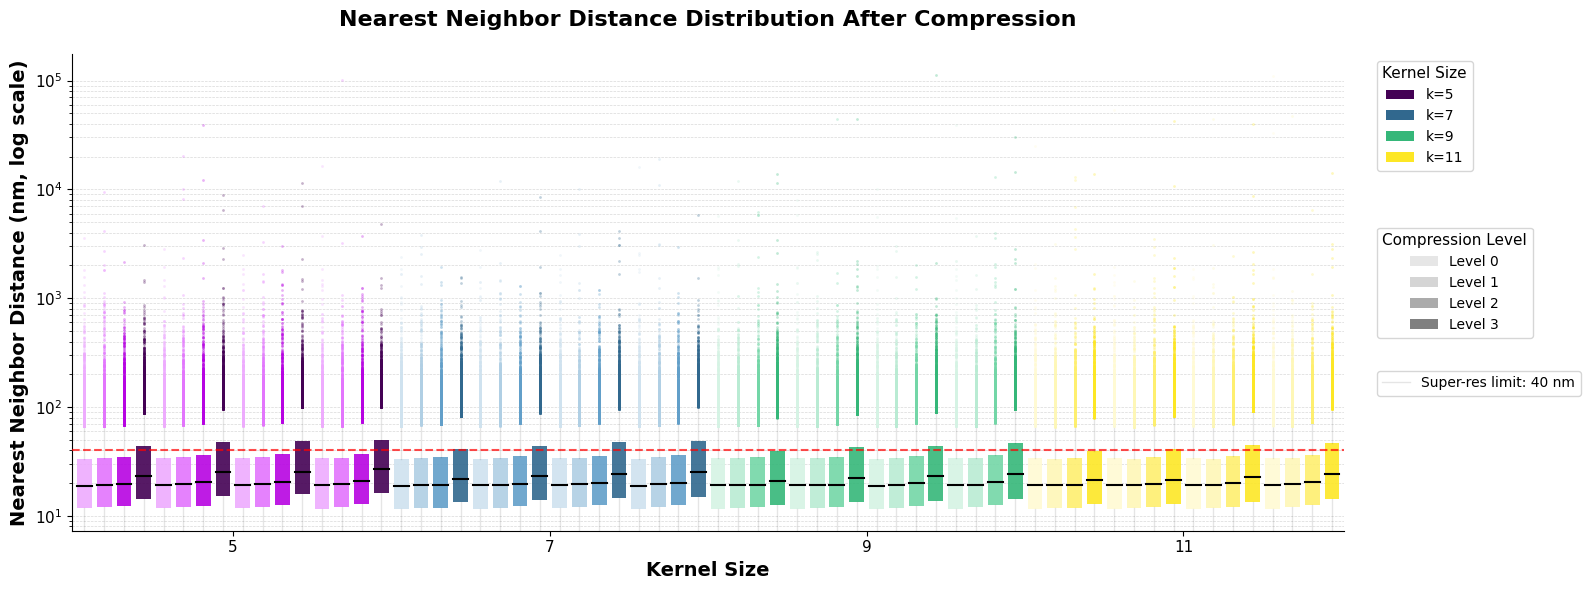

NEAREST NEIGHBOR DISTANCE SUMMARY

Raw median NN distance: 19.17 nm
Raw mean NN distance: 33.68 nm
Super-resolution limit: 40 nm
Total conditions tested: 64

Compressed median NN range: 19.01 - 26.72 nm
Average median NN: 20.47 nm

Conditions with median NN > 40 nm: 0 (0.0%)
Conditions with median NN ≤ 40 nm: 64 (100.0%)

Closest to 40 nm threshold:
            Folder  median_nn  diff_from_40  k  lev  threshold
sparz_k5_rt65_lev3  26.717100     13.282900  5    3         65
sparz_k5_rt55_lev3  25.551556     14.448444  5    3         55
sparz_k7_rt65_lev3  25.332063     14.667937  7    3         65
sparz_k5_rt45_lev3  25.106848     14.893152  5    3         45
sparz_k7_rt55_lev3  24.403693     15.596307  7    3         55

Largest NN distances:
            Folder  median_nn  k  lev  threshold
sparz_k5_rt65_lev3  26.717100  5    3         65
sparz_k5_rt55_lev3  25.551556  5    3         55
sparz_k7_rt65_lev3  25.332063  7    3         65
sparz_k5_rt45_lev3  25.106848  5    3         45
sp

In [ ]:
# ============================================================================
# Calculate Nearest Neighbor Distances for All Conditions
# ============================================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
from pathlib import Path
from sklearn.neighbors import NearestNeighbors

# Import from h5r_functions directly
from h5r_functions import get_xyz_coordinates

# Import utility functions
from analysis_utils import extract_k_lev, lighten_color

# ============================================================================
# Configuration
# ============================================================================

# Data paths
DROPBOX_BASE = Path("/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_2_data")
localizations_folder = DROPBOX_BASE / "localizations" / "sparz_grid_search"
raw_localizations_file = localizations_folder / "raw" / "analysis" / "sequence-MT0.N1.HD-BP.h5r"

# Output paths
output_csv = Path("/Users/laurabreimann/Desktop/microtubule_nn_distances.csv")
output_figure = Path("/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_2_NN_distances_boxplot.pdf")

# ============================================================================
# Function to Calculate Nearest Neighbor Distances
# ============================================================================

def calculate_nn_distances(locs, n_neighbors=2):
    """
    Calculate nearest neighbor distances for 3D point cloud.
    
    Parameters:
    -----------
    locs : pd.DataFrame
        DataFrame with x, y, z columns
    n_neighbors : int
        Number of neighbors (2 means distance to 1st neighbor, excluding self)
        
    Returns:
    --------
    np.ndarray
        Array of nearest neighbor distances
    """
    if len(locs) < 2:
        return np.array([])
    
    # Fit nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree').fit(locs)
    distances, indices = nbrs.kneighbors(locs)
    
    # Return distances to first neighbor (index 1, since index 0 is self)
    return distances[:, 1]

# ============================================================================
# Calculate NN Distances for All Conditions
# ============================================================================

print(f"\n{'='*80}")
print("CALCULATING NEAREST NEIGHBOR DISTANCES")
print(f"{'='*80}\n")

if not raw_localizations_file.exists():
    raise FileNotFoundError(f"Raw localization file not found: {raw_localizations_file}")

# Read raw localizations once
print("Reading raw localizations...")
raw_locs = get_xyz_coordinates(str(raw_localizations_file))
print(f"Raw localizations: {len(raw_locs):,} points")
print("Calculating raw NN distances...")
raw_nn_distances = calculate_nn_distances(raw_locs)
print(f"Raw median NN distance: {np.median(raw_nn_distances):.2f} nm\n")

nn_results = []

for folder in natsorted(os.listdir(localizations_folder)):
    if folder.startswith('.') or folder == 'raw' or not folder.startswith('sparz_'):
        continue
    
    print(f"Processing: {folder}")
    
    compressed_file = localizations_folder / folder / "analysis" / "sequence-MT0.N1.HD-BP.h5r"
    
    if not compressed_file.exists():
        print(f"  Warning: Localization file not found")
        continue
    
    try:
        # Read compressed localizations
        compressed_locs = get_xyz_coordinates(str(compressed_file))
        print(f"  Compressed localizations: {len(compressed_locs):,}")
        
        # Calculate NN distances
        nn_distances = calculate_nn_distances(compressed_locs)
        
        if len(nn_distances) > 0:
            median_nn = np.median(nn_distances)
            mean_nn = np.mean(nn_distances)
            print(f"  Median NN distance: {median_nn:.2f} nm")
            print(f"  Mean NN distance: {mean_nn:.2f} nm")
        else:
            print(f"  Warning: No NN distances calculated")
            continue
        
        # Extract parameters from folder name
        k, lev = extract_k_lev(folder)
        threshold_match = re.search(r'rt(\d+)', folder)
        threshold = int(threshold_match.group(1)) if threshold_match else None
        
        nn_results.append({
            'Folder': folder,
            'nn_distances': nn_distances,
            'median_nn': median_nn,
            'mean_nn': mean_nn,
            'k': k,
            'lev': lev,
            'threshold': threshold
        })
        
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"Total conditions processed: {len(nn_results)}")
print(f"{'='*80}\n")

# Save summary statistics to CSV
summary_data = [{
    'Folder': r['Folder'],
    'median_nn': r['median_nn'],
    'mean_nn': r['mean_nn'],
    'k': r['k'],
    'lev': r['lev'],
    'threshold': r['threshold']
} for r in nn_results]

nn_summary_df = pd.DataFrame(summary_data)
nn_summary_df.to_csv(output_csv, index=False)
print(f"Summary statistics saved to: {output_csv}\n")

# ============================================================================
# Create Box Plot with Kernel Grouping (Log Scale)
# ============================================================================

# Get unique values and sort them
k_values = sorted(set([r['k'] for r in nn_results]))
threshold_values = sorted(set([r['threshold'] for r in nn_results]))
compression_levels = sorted(set([r['lev'] for r in nn_results]))

print(f"Kernel sizes: {k_values}")
print(f"Thresholds: {threshold_values}")
print(f"Compression levels: {compression_levels}\n")

# Create base colors for kernel sizes (same as other plots)
k_base_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
k_color_map = {k: color for k, color in zip(k_values, k_base_colors)}

# Saturation levels for compression levels
saturation_levels = {
    0: 0.2,   # Lightest
    1: 0.33,  # Light-medium
    2: 0.66,  # Medium-dark  
    3: 1.0    # Darkest
}

# Function to get color based on kernel size and compression level
def get_color(k, lev):
    """Get color based on kernel size and compression level."""
    base_color = k_color_map[k]
    amount = saturation_levels[lev]
    return lighten_color(base_color, amount)

# Prepare data for plotting
fig, ax = plt.subplots(figsize=(16, 6))

# Calculate dimensions
n_kernels = len(k_values)
n_thresholds = len(threshold_values)
n_levels = len(compression_levels)
box_width = 0.6
box_spacing = 0.2

x_positions = []
data_for_boxplot = []
colors_for_boxes = []
x_current = 0

# Store positions for kernel group centers
kernel_group_centers = []

# Iterate: Kernels -> Thresholds -> Compression Levels
for i, k in enumerate(k_values):
    kernel_start = x_current
    
    for j, threshold in enumerate(threshold_values):
        for l, lev in enumerate(compression_levels):
            # Find the data point
            data_point = [r for r in nn_results 
                         if r['k'] == k and r['threshold'] == threshold and r['lev'] == lev]
            
            if len(data_point) > 0:
                # Add position
                x_positions.append(x_current)
                
                # Get NN distances
                data_for_boxplot.append(data_point[0]['nn_distances'])
                
                # Get color
                color = get_color(k, lev)
                colors_for_boxes.append(color)
                
                # Move to next box position
                x_current += box_width + box_spacing
    
    # Calculate center of this kernel group
    kernel_end = x_current
    kernel_group_centers.append((kernel_start + kernel_end - box_width - box_spacing) / 2)

# Create box plot
bp = ax.boxplot(data_for_boxplot, positions=x_positions, widths=box_width,
                patch_artist=True,  # Enable coloring
                showfliers=True,    # Show outliers
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.5, alpha=0.1),  
                capprops=dict(color='black', linewidth=0, alpha=0),      # Hide caps
                flierprops=dict(marker='o', markersize=2, alpha=0.3, 
                              markeredgecolor='none'),  # Style outliers
                boxprops=dict(linewidth=0))  # No box edges

# Color the boxes
for patch, color, fliers in zip(bp['boxes'], colors_for_boxes, bp['fliers']):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)
    patch.set_edgecolor('none')  # Remove box edges
    # Match flier color to box color
    fliers.set_markerfacecolor(color)
    fliers.set_markeredgecolor('none')
    fliers.set_alpha(0.3)

# Set y-axis to logarithmic scale
ax.set_yscale('log')

# Add reference line at 40 nm (super-resolution limit)
ax.axhline(y=40, color='red', linestyle='--', 
          linewidth=1.5, alpha=0.7, label='Super-res limit: 40 nm', zorder=10)

# Customize plot
ax.set_xlabel('Kernel Size', fontsize=14, fontweight='bold')
ax.set_ylabel('Nearest Neighbor Distance (nm, log scale)', fontsize=14, fontweight='bold')
ax.set_title('Nearest Neighbor Distance Distribution After Compression', 
             fontsize=16, fontweight='bold', pad=20)

# Set x-axis labels at kernel group centers
ax.set_xticks(kernel_group_centers)
ax.set_xticklabels([f'{k}' for k in k_values], fontsize=12)

# Add grid
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0, which='both')
ax.set_axisbelow(True)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=11)

# Remove extra space around boxes
ax.margins(x=0.01)

# Create custom legends
from matplotlib.patches import Patch

# Legend 1: Kernel sizes (colors)
legend_elements_k = [
    Patch(facecolor=k_color_map[k], edgecolor='none', label=f'k={k}')
    for k in k_values
]

# Legend 2: Compression levels (saturations)
legend_elements_lev = []
sample_base_color = np.array([0.5, 0.5, 0.5, 1.0])
for lev in compression_levels:
    amount = saturation_levels[lev]
    color = lighten_color(sample_base_color, amount)
    legend_elements_lev.append(Patch(facecolor=color, edgecolor='none', label=f'Level {lev}'))

# Add legends
legend1 = ax.legend(handles=legend_elements_k, loc='upper left', 
                    bbox_to_anchor=(1.02, 1), title='Kernel Size', 
                    fontsize=10, title_fontsize=11, frameon=True)
legend2 = ax.legend(handles=legend_elements_lev, loc='upper left', 
                    bbox_to_anchor=(1.02, 0.65), title='Compression Level', 
                    fontsize=10, title_fontsize=11, frameon=True)

# Add back the reference line legend
legend3 = ax.legend([ax.get_lines()[0]], 
                   ['Super-res limit: 40 nm'],
                   loc='upper left', bbox_to_anchor=(1.02, 0.35), 
                   fontsize=10, frameon=True)

ax.add_artist(legend1)
ax.add_artist(legend2)

plt.tight_layout()

# Save figure
output_figure.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_figure, format='pdf', bbox_inches='tight', dpi=300)
print(f"Figure saved to: {output_figure}\n")

plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================

print(f"{'='*80}")
print(f"NEAREST NEIGHBOR DISTANCE SUMMARY")
print(f"{'='*80}\n")

print(f"Raw median NN distance: {np.median(raw_nn_distances):.2f} nm")
print(f"Raw mean NN distance: {np.mean(raw_nn_distances):.2f} nm")
print(f"Super-resolution limit: 40 nm")
print(f"Total conditions tested: {len(nn_results)}\n")

print(f"Compressed median NN range: {nn_summary_df['median_nn'].min():.2f} - {nn_summary_df['median_nn'].max():.2f} nm")
print(f"Average median NN: {nn_summary_df['median_nn'].mean():.2f} nm\n")

# Check how many conditions are above/below 40nm threshold
above_40 = nn_summary_df[nn_summary_df['median_nn'] > 40]
below_40 = nn_summary_df[nn_summary_df['median_nn'] <= 40]
print(f"Conditions with median NN > 40 nm: {len(above_40)} ({100*len(above_40)/len(nn_summary_df):.1f}%)")
print(f"Conditions with median NN ≤ 40 nm: {len(below_40)} ({100*len(below_40)/len(nn_summary_df):.1f}%)\n")

print("Closest to 40 nm threshold:")
nn_summary_df['diff_from_40'] = abs(nn_summary_df['median_nn'] - 40)
closest_to_40 = nn_summary_df.nsmallest(5, 'diff_from_40')
print(closest_to_40[['Folder', 'median_nn', 'diff_from_40', 'k', 'lev', 'threshold']].to_string(index=False))

print("\nLargest NN distances:")
largest_nn = nn_summary_df.nlargest(5, 'median_nn')
print(largest_nn[['Folder', 'median_nn', 'k', 'lev', 'threshold']].to_string(index=False))

print("\nSmallest NN distances:")
smallest_nn = nn_summary_df.nsmallest(5, 'median_nn')
print(smallest_nn[['Folder', 'median_nn', 'k', 'lev', 'threshold']].to_string(index=False))

# Group statistics
print(f"\n{'-'*80}")
print("Median NN Distance by Compression Level:")
print(f"{'-'*80}")
level_stats = nn_summary_df.groupby('lev')['median_nn'].agg(['mean', 'std', 'min', 'max'])
print(level_stats)

print(f"\n{'-'*80}")
print("Median NN Distance by Kernel Size:")
print(f"{'-'*80}")
kernel_stats = nn_summary_df.groupby('k')['median_nn'].agg(['mean', 'std', 'min', 'max'])
print(kernel_stats)

print(f"\n{'-'*80}")
print("Median NN Distance by Threshold:")
print(f"{'-'*80}")
threshold_stats = nn_summary_df.groupby('threshold')['median_nn'].agg(['mean', 'std', 'min', 'max'])
print(threshold_stats)


## Biplane PSF simulation for figure

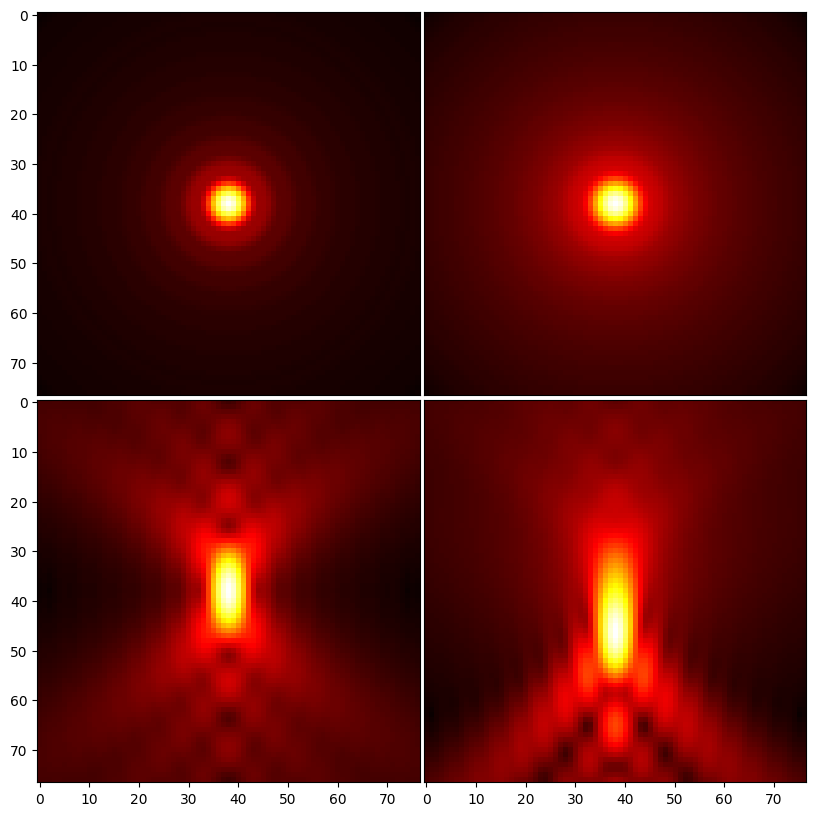

In [10]:
import psfmodels as psfm
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Generate centered PSF with a point source at `pz` microns from coverslip
# In-focus PSF
psf_in_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=0)

# Out-of-focus PSF
psf_out_of_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=10)  # Adjust pz for out-of-focus condition

# Plot the results
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

# XY View - In Focus
axs[0, 0].imshow(psf_in_focus[38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[0, 0].set_title('Biplane 1 - XY View')
#Remove ticks
axs[0, 0].set_xticks([])

# XY View - Out of Focus
axs[0, 1].imshow(psf_out_of_focus[38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[0, 1].set_title('Biplane 2 - XY View')
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])

# ZX View - In Focus
axs[1, 0].imshow(psf_in_focus[:, 38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[1, 0].set_title('Biplane 1 - ZX View')

# ZX View - Out of Focus
axs[1, 1].imshow(psf_out_of_focus[:, 38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[1, 1].set_title('Biplane 2 - ZX View')
axs[1, 1].set_yticks([])


plt.tight_layout(pad=.1)
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/biplane_PSF.png')
plt.show()
